# Analysis


In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
df_before = pd.read_csv(r"D:\Thesis\mentaldata\mentaldataset_clean.csv")

# Indicator section: tu dietary_habit den self_harm
indicator_cols = df_before.columns[
    df_before.columns.get_loc("dietary_habit") : df_before.columns.get_loc("self_harm") + 1
].tolist()
print("Indicator columns:", indicator_cols)

# Mental health: dung trung binh anxiety & depression
df_before["MH_mean"] = df_before[["anxiety", "depression"]].mean(axis=1)

# Intent to quit: 0 = khong, 1 = co (3 hoac 5)
df_before["IntentQuit_bin"] = (
    df_before["intent_to_quit"].replace({1: 0, 3: 1, 5: 1}).astype("int64")
)

# X cho tat ca phan tich (indicator section)
X = df_before[indicator_cols].copy()
# Scale X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# y cho tung bai toan
y_mh   = df_before["MH_mean"]
y_quit = df_before["IntentQuit_bin"]

print("X shape:", X.shape)
print("y_mh shape:", y_mh.shape)
print("y_quit value counts:\n", y_quit.value_counts())

df_before.to_csv("df_before_with_MH_Intent.csv", index=False, encoding="utf-8")

Indicator columns: ['dietary_habit', 'nicotine_use', 'work_hours', 'AP1', 'AP2', 'AP3', 'AP4', 'FS1', 'FS2', 'FS3', 'FP1', 'FP2', 'SS1', 'SS2', 'SS3', 'sleep_duration', 'anxiety', 'depression', 'short_term_memory', 'family_history', 'self_harm']
X shape: (124, 21)
y_mh shape: (124,)
y_quit value counts:
 IntentQuit_bin
0    100
1     24
Name: count, dtype: int64


In [2]:
from sklearn.cluster import KMeans
import numpy as np

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_before["cluster_k3"] = kmeans.fit_predict(X_scaled)

# So luong tung cum
cluster_counts = df_before["cluster_k3"].value_counts().sort_index()
print("Cluster sizes:")
print(cluster_counts)


centers_scaled = kmeans.cluster_centers_
centers_orig = scaler.inverse_transform(centers_scaled)
cluster_centers_orig = pd.DataFrame(
    centers_orig,
    columns=indicator_cols
)
cluster_centers_orig.index.name = "cluster"
print("\nCluster centers (original scale):")
print(cluster_centers_orig.round(2))

# cluster_counts.to_csv("kmeans_cluster_sizes_k3.csv", header=["count"])
cluster_centers_orig.round(2).to_csv("kmeans_cluster_centers_k3.csv")

Cluster sizes:
cluster_k3
0    34
1    17
2    73
Name: count, dtype: int64

Cluster centers (original scale):
         dietary_habit  nicotine_use  work_hours   AP1   AP2   AP3   AP4  \
cluster                                                                    
0                 3.12          1.24        1.41  3.88  4.32  4.41  3.76   
1                 2.18          2.41        2.12  2.47  2.18  2.76  2.41   
2                 2.56          1.11        1.71  3.03  3.62  4.03  3.36   

          FS1   FS2   FS3  ...   FP2   SS1   SS2   SS3  sleep_duration  \
cluster                    ...                                           
0        3.21  2.62  2.50  ...  4.15  3.74  3.06  3.74            2.35   
1        1.88  1.53  1.47  ...  1.88  2.24  1.65  2.12            1.82   
2        3.44  3.19  2.96  ...  3.33  2.60  2.16  2.58            1.90   

         anxiety  depression  short_term_memory  family_history  self_harm  
cluster                                                     

In [3]:
from sklearn.decomposition import PCA

pca = PCA(n_components=X.shape[1])
pca.fit(X_scaled)

# Eigenvalue va explained variance
explained = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(X.shape[1])],
    "eigenvalue": pca.explained_variance_,
    "explained_variance_ratio": pca.explained_variance_ratio_
})
print("PCA explained variance:")
print(explained.head(10))

# explained.to_csv("pca_explained_variance_indicators.csv", index=False)

# Loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=indicator_cols,
    columns=[f"PC{i+1}" for i in range(X.shape[1])]
)
print("\nPCA loadings (first 5 components):")
print(loadings.iloc[:, :5].round(3))

# loadings.round(3).to_csv("pca_loadings_indicators.csv", index_label="variable")


PCA explained variance:
  component  eigenvalue  explained_variance_ratio
0       PC1    4.146578                  0.195864
1       PC2    2.397924                  0.113266
2       PC3    1.950897                  0.092151
3       PC4    1.826724                  0.086285
4       PC5    1.536222                  0.072563
5       PC6    1.321302                  0.062412
6       PC7    1.069049                  0.050497
7       PC8    0.897413                  0.042389
8       PC9    0.799170                  0.037749
9      PC10    0.662264                  0.031282

PCA loadings (first 5 components):
                     PC1    PC2    PC3    PC4    PC5
dietary_habit     -0.177  0.083  0.199  0.148  0.090
nicotine_use       0.058  0.142  0.400  0.336 -0.002
work_hours         0.044 -0.011  0.160  0.219 -0.287
AP1               -0.318  0.006  0.330  0.030 -0.115
AP2               -0.326 -0.134  0.308 -0.070 -0.053
AP3               -0.243 -0.258  0.239 -0.180  0.103
AP4               -

In [4]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Bo anxiety, depression khoi predictors vi da dung tao MH_mean
predictor_cols_mh = [
    c for c in indicator_cols 
    if c not in ["anxiety", "depression", "self_harm"]
]

X_mh = df_before[predictor_cols_mh]
X_mh_const = sm.add_constant(X_mh)

model_mh = sm.OLS(y_mh, X_mh_const).fit()
print(model_mh.summary())

coef_mh = model_mh.params.to_frame(name="coef")
# coef_mh.to_csv("linear_reg_indicators_to_MHmean_coefs.csv")


                            OLS Regression Results                            
Dep. Variable:                MH_mean   R-squared:                       0.377
Model:                            OLS   Adj. R-squared:                  0.270
Method:                 Least Squares   F-statistic:                     3.523
Date:                Fri, 09 Jan 2026   Prob (F-statistic):           2.45e-05
Time:                        15:03:40   Log-Likelihood:                -209.14
No. Observations:                 124   AIC:                             456.3
Df Residuals:                     105   BIC:                             509.9
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.7610      0.87

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_quit, test_size=0.3, random_state=42, stratify=y_quit
)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix (KNN):")
print(cm)

print("\nClassification report (KNN):")
print(classification_report(y_test, y_pred, digits=3))

cm_df = pd.DataFrame(cm, index=["True_0","True_1"], columns=["Pred_0","Pred_1"])
cm_df.to_csv("knn_confusion_matrix_intentquit.csv")


Confusion matrix (KNN):
[[30  1]
 [ 5  2]]

Classification report (KNN):
              precision    recall  f1-score   support

           0      0.857     0.968     0.909        31
           1      0.667     0.286     0.400         7

    accuracy                          0.842        38
   macro avg      0.762     0.627     0.655        38
weighted avg      0.822     0.842     0.815        38



In [6]:
from lazypredict.Supervised import LazyClassifier

clf = LazyClassifier(
    verbose=0,
    ignore_warnings=True,
    custom_metric=None,
    random_state=42
)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

print("Top models:")
print(models.head(10))

models.to_csv("lazypredict_models_intentquit.csv")

  0%|          | 0/29 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 17, number of negative: 69
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000037 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 101
[LightGBM] [Info] Number of data points in the train set: 86, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.197674 -> initscore=-1.400893
[LightGBM] [Info] Start training from score -1.400893
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L

In [7]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# rf_clf = RandomForestClassifier(
#     random_state=42,
# )
# rf_clf.fit(X_train, y_train)

# y_pred_rf = rf_clf.predict(X_test)
# y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

# print("\n=== Random Forest metrics ===")
# print("AUC ROC:", roc_auc_score(y_test, y_proba_rf))

# cm_rf = confusion_matrix(y_test, y_pred_rf)
# cm_rf_df = pd.DataFrame(
#     cm_rf,
#     index=["True_0_NoQuit", "True_1_Quit"],
#     columns=["Pred_0_NoQuit", "Pred_1_Quit"]
# )
# print("\nConfusion matrix (RandomForest):")
# print(cm_rf_df)

# print("\nClassification report (RandomForest):")
# print(classification_report(y_test, y_pred_rf, digits=3))

# # Feature importance
# importances = rf_clf.feature_importances_
# imp_df = pd.DataFrame({
#     "feature": indicator_cols,
#     "importance": importances
# }).sort_values("importance", ascending=False)

# print("\nTop features (RandomForest):")
# print(imp_df.head(10))

In [8]:
# from sklearn.ensemble import ExtraTreesClassifier
# from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
# import pandas as pd
# import numpy as np

# # 1) Train ExtraTrees
# et = ExtraTreesClassifier(
#     random_state=42,
# )
# # et = ExtraTreesClassifier(
# #     n_estimators=300,
# #     random_state=42,
# #     class_weight="balanced",  # giup can bang lop 0/1
# #     n_jobs=-1
# # )
# et.fit(X_train, y_train)

# # 2) Du doan
# y_pred_et = et.predict(X_test)
# y_proba_et = et.predict_proba(X_test)[:, 1]

# # 3) Metrics tong quat
# print("=== ExtraTreesClassifier metrics ===")
# print("AUC ROC:", roc_auc_score(y_test, y_proba_et))

# cm_et = confusion_matrix(y_test, y_pred_et)
# cm_et_df = pd.DataFrame(
#     cm_et,
#     index=["True_0_NoQuit", "True_1_Quit"],
#     columns=["Pred_0_NoQuit", "Pred_1_Quit"]
# )
# print("\nConfusion matrix (ExtraTrees):")
# print(cm_et_df)

# print("\nClassification report (ExtraTrees):")
# print(classification_report(y_test, y_pred_et, digits=3))


# # # cm_et_df.to_csv("extratrees_confusion_matrix_intentquit.csv")
# # # feat_imp_et.to_csv("extratrees_feature_importances_intentquit.csv", index=False)


In [9]:
# from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
# from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
# import pandas as pd

# # QDA
# qda = QuadraticDiscriminantAnalysis()
# qda.fit(X_train, y_train)

# y_pred_qda = qda.predict(X_test)
# y_proba_qda = qda.predict_proba(X_test)[:, 1]

# print("\n=== QuadraticDiscriminantAnalysis metrics ===")
# print("AUC ROC:", roc_auc_score(y_test, y_proba_qda))

# cm_qda = confusion_matrix(y_test, y_pred_qda)
# cm_qda_df = pd.DataFrame(
#     cm_qda,
#     index=["True_0_NoQuit", "True_1_Quit"],
#     columns=["Pred_0_NoQuit", "Pred_1_Quit"]
# )

# print("\nConfusion matrix (QDA):")
# print(cm_qda_df)

# print("\nClassification report (QDA):")
# print(classification_report(y_test, y_pred_qda, digits=3))

Saved: models_before.csv


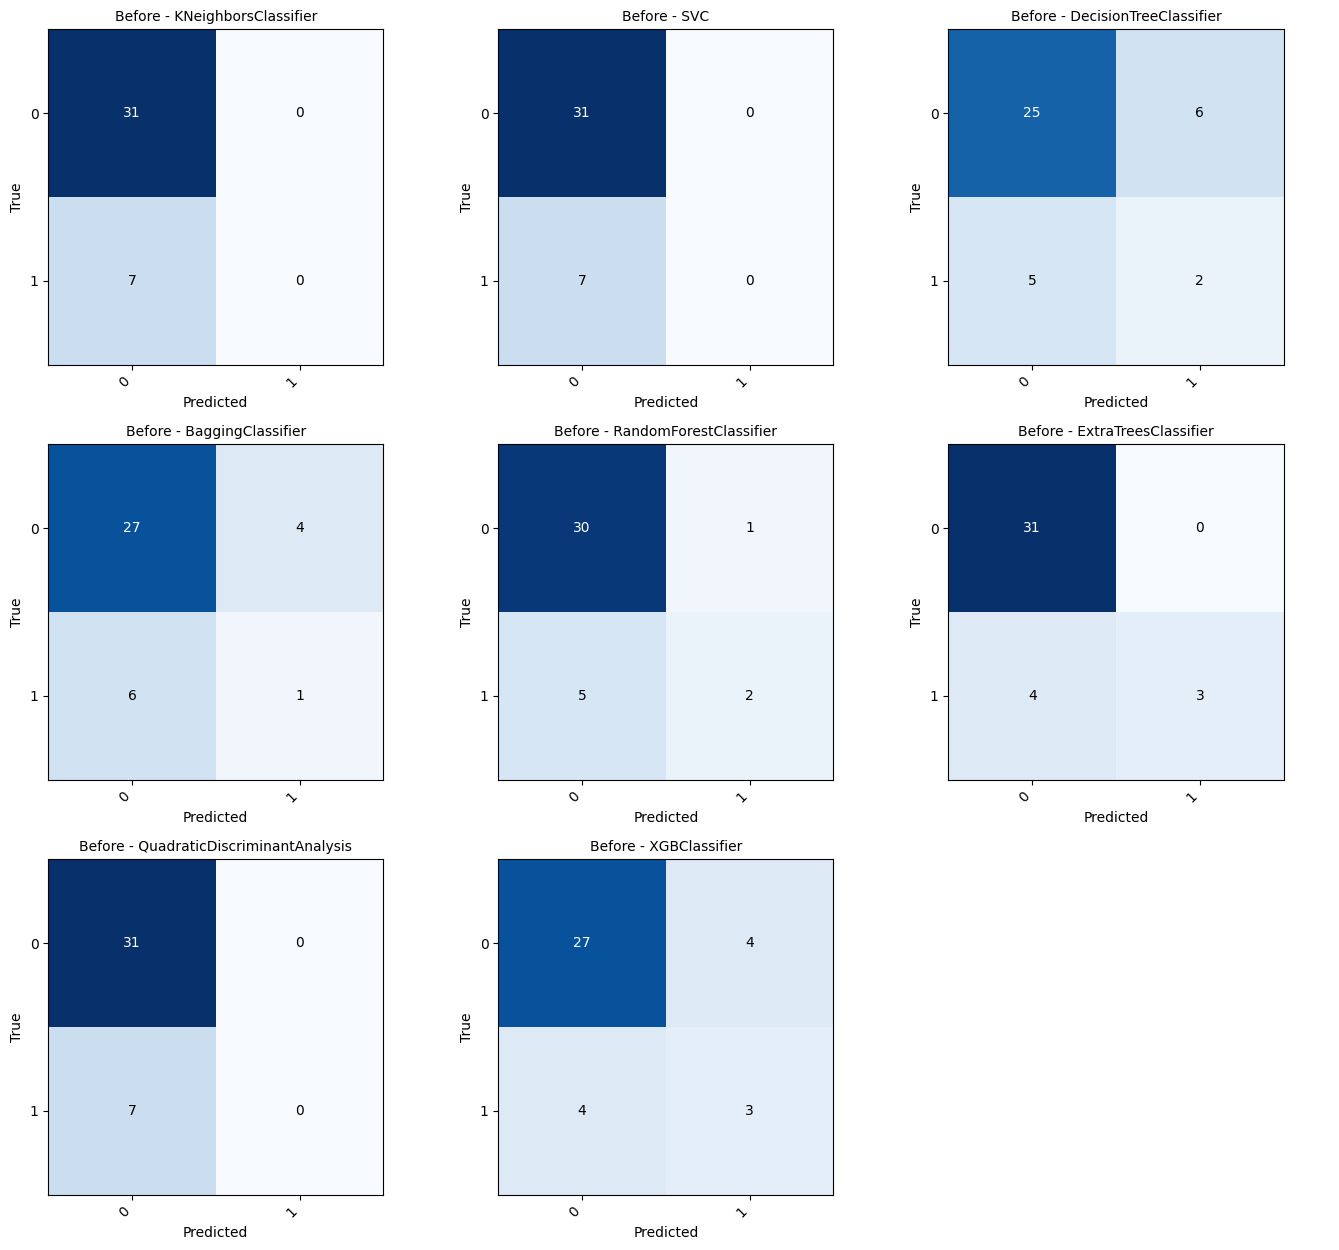

In [10]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.base import clone

# XGB optional
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False


# ------------------------------------------------------------
# LazyPredict-like preprocessing
# ------------------------------------------------------------
def _onehot():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def _to_df(X, ref_cols=None):
    if isinstance(X, pd.DataFrame):
        return X
    if isinstance(X, np.ndarray):
        if ref_cols is None:
            return pd.DataFrame(X)
        return pd.DataFrame(X, columns=list(ref_cols))
    return pd.DataFrame(X)


def get_card_split(df, cols, n=11):
    if len(cols) == 0:
        return cols, cols
    nun = df[cols].nunique(dropna=True)
    high = nun[nun > n].index
    low = [c for c in cols if c not in set(high)]
    return low, list(high)


def build_lazypredict_preprocessor(X_train_df):
    # Numeric: impute mean + scale
    num_cols = X_train_df.select_dtypes(include=[np.number]).columns.tolist()

    # Categorical: object/category/bool
    cat_cols = X_train_df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    cat_low, cat_high = get_card_split(X_train_df, cat_cols, n=11)

    numeric_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="mean")),
            ("scaler", StandardScaler()),
        ]
    )

    cat_low_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
            ("onehot", _onehot()),
        ]
    )

    cat_high_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
            ("ordinal", OrdinalEncoder()),
        ]
    )

    pre = ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipe, num_cols),
            ("categorical_low", cat_low_pipe, cat_low),
            ("categorical_high", cat_high_pipe, cat_high),
        ],
        remainder="drop",
    )
    return pre


# ------------------------------------------------------------
# Models (close to LazyPredict defaults)
# ------------------------------------------------------------
def build_models(n_classes, seed=42):
    models = {
        "KNeighborsClassifier": KNeighborsClassifier(),
        "SVC": SVC(kernel="rbf", probability=True),
        "DecisionTreeClassifier": DecisionTreeClassifier(),
        "BaggingClassifier": BaggingClassifier(),
        "RandomForestClassifier": RandomForestClassifier(),
        "ExtraTreesClassifier": ExtraTreesClassifier(),
        "QuadraticDiscriminantAnalysis": QuadraticDiscriminantAnalysis(),
    }

    if HAS_XGB:
        if n_classes == 2:
            models["XGBClassifier"] = XGBClassifier(
                eval_metric="logloss",
                use_label_encoder=False,
            )
        else:
            models["XGBClassifier"] = XGBClassifier(
                eval_metric="mlogloss",
                use_label_encoder=False,
            )

    # LazyPredict sets random_state only if supported
    for k in list(models.keys()):
        est = models[k]
        try:
            params = est.get_params()
            if "random_state" in params:
                est.set_params(random_state=seed)
        except Exception:
            pass

    return models


# ------------------------------------------------------------
# Metrics helpers (LazyPredict-like AUC)
# ------------------------------------------------------------
def auc_like_lazypredict(y_true, y_pred):
    # LazyPredict often uses hard labels for AUC, and can fail for multiclass
    try:
        return roc_auc_score(y_true, y_pred)
    except Exception:
        return np.nan


def safe_sorted_labels(y):
    u = pd.unique(pd.Series(y))
    try:
        return np.array(sorted(u))
    except Exception:
        return np.array(u)


def plot_confusion_matrices_grid(cms, labels, title_prefix="", cmap="Blues"):
    model_names = list(cms.keys())
    n = len(model_names)
    if n == 0:
        return

    cols = 3
    rows = int(np.ceil(n / cols))

    vmax = 1
    for cm in cms.values():
        try:
            vmax = max(vmax, int(np.max(cm)))
        except Exception:
            pass

    fig, axes = plt.subplots(rows, cols, figsize=(4.6 * cols, 4.2 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, name in zip(axes, model_names):
        cm = cms[name]
        ax.imshow(cm, cmap=cmap, vmin=0, vmax=vmax)

        ax.set_title(f"{title_prefix}{name}", fontsize=10)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

        ax.set_xticks(range(len(labels)))
        ax.set_yticks(range(len(labels)))
        ax.set_xticklabels([str(x) for x in labels], rotation=45, ha="right")
        ax.set_yticklabels([str(x) for x in labels])

        thresh = vmax * 0.55
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                val = int(cm[i, j])
                ax.text(
                    j, i, str(val),
                    ha="center", va="center",
                    color="white" if val > thresh else "black",
                    fontsize=10,
                )

    for ax in axes[len(model_names) :]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Main runner (pipeline for ALL models, like LazyPredict)
# ------------------------------------------------------------
def run_models_and_export_csv(
    X_train,
    X_test,
    y_train,
    y_test,
    run_name="",
    out_csv="models_metrics.csv",
    seed=42,
    cm_cmap="Blues",
    display_round=6,
):
    y_train = np.array(y_train).ravel()
    y_test = np.array(y_test).ravel()

    X_train_df = _to_df(X_train)
    X_test_df = _to_df(X_test, ref_cols=X_train_df.columns)

    labels = safe_sorted_labels(np.concatenate([y_train, y_test]))
    n_classes = len(pd.unique(pd.Series(labels)))

    preprocessor = build_lazypredict_preprocessor(X_train_df)
    models = build_models(n_classes=n_classes, seed=seed)

    rows = []
    cms = {}

    for name, base_model in models.items():
        try:
            t0 = time.perf_counter()

            pipe = Pipeline(
                steps=[
                    ("preprocessor", clone(preprocessor)),
                    ("classifier", clone(base_model)),
                ]
            )

            pipe.fit(X_train_df, y_train)
            y_pred = pipe.predict(X_test_df)

            elapsed = time.perf_counter() - t0

            row = {
                "Model": name,
                "Accuracy": accuracy_score(y_test, y_pred),
                "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
                "AUC ROC": auc_like_lazypredict(y_test, y_pred),
                "F1 Score": f1_score(y_test, y_pred, average="weighted", zero_division=0),
                "Time Taken": elapsed,
                "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
                "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
            }
            rows.append(row)

            cms[name] = confusion_matrix(y_test, y_pred, labels=labels)

        except Exception as e:
            print(f"[WARN] {name} failed: {e}")
            rows.append(
                {
                    "Model": name,
                    "Accuracy": np.nan,
                    "Balanced Accuracy": np.nan,
                    "AUC ROC": np.nan,
                    "F1 Score": np.nan,
                    "Time Taken": np.nan,
                    "Precision": np.nan,
                    "Recall": np.nan,
                }
            )

    df = pd.DataFrame(rows)
    df = df.sort_values(["Accuracy", "Balanced Accuracy"], ascending=False).reset_index(drop=True)

    if out_csv:
        df.to_csv(out_csv, index=False)
        print(f"Saved: {out_csv}")

    plot_confusion_matrices_grid(
        cms=cms,
        labels=labels,
        title_prefix=run_name,
        cmap=cm_cmap,
    )

    # nicer notebook display
    if display_round is not None:
        show_df = df.copy()
        for c in ["Accuracy", "Balanced Accuracy", "AUC ROC", "F1 Score", "Precision", "Recall", "Time Taken"]:
            show_df[c] = show_df[c].astype(float).round(display_round)
        return show_df, df, cms

    return df, df, cms


# ------------------------------------------------------------
# USAGE
# ------------------------------------------------------------

# BEFORE SMOTE (use the same split as LazyPredict)
df_before_show, df_before_full, cms_before = run_models_and_export_csv(
    X_train, X_test, y_train, y_test,
    run_name="Before - ",
    out_csv="models_before.csv",
    seed=42,
    cm_cmap="Blues",
    display_round=6,
)

# AFTER SMOTE (optional)
# df_after_show, df_after_full, cms_after = run_models_and_export_csv(
#     X_train_smote, X_test_smote, y_train_smote, y_test_smote,
#     run_name="After SMOTE - ",
#     out_csv="models_after_smote.csv",
#     seed=42,
#     cm_cmap="Blues",
#     display_round=6,
# )


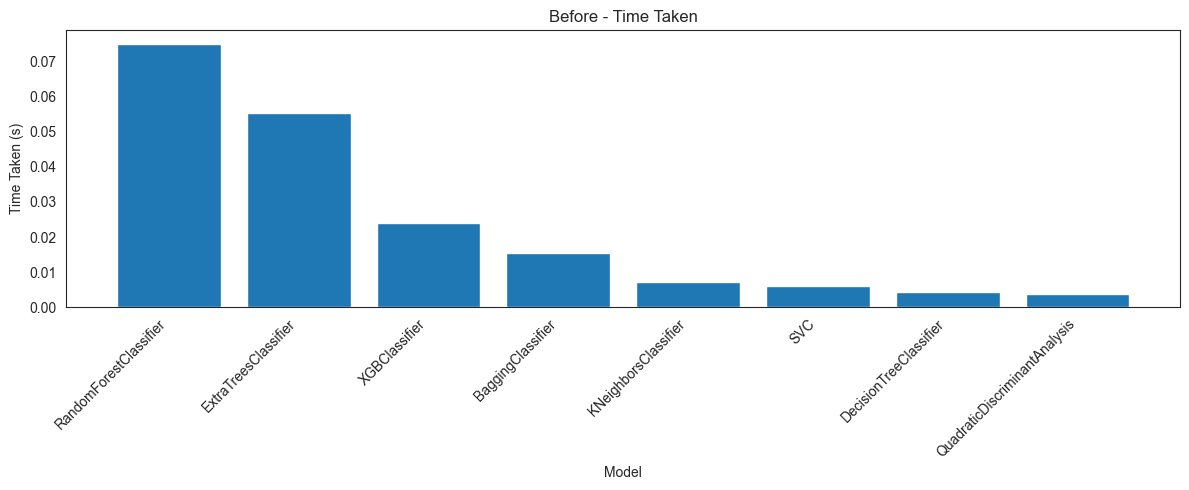

In [ ]:
def plot_time_taken_bar(df, title="Time Taken by Model"):
    # Expects columns: "Model", "Time Taken"
    d = df[["Model", "Time Taken"]].copy()
    d["Time Taken"] = pd.to_numeric(d["Time Taken"], errors="coerce")
    d = d.dropna().sort_values("Time Taken", ascending=False)

    plt.figure(figsize=(12, 5))
    plt.bar(d["Model"], d["Time Taken"])
    plt.xlabel("Model")
    plt.ylabel("Time Taken (s)")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


# Example:
plot_time_taken_bar(df_before_full, title="Before - Time Taken")

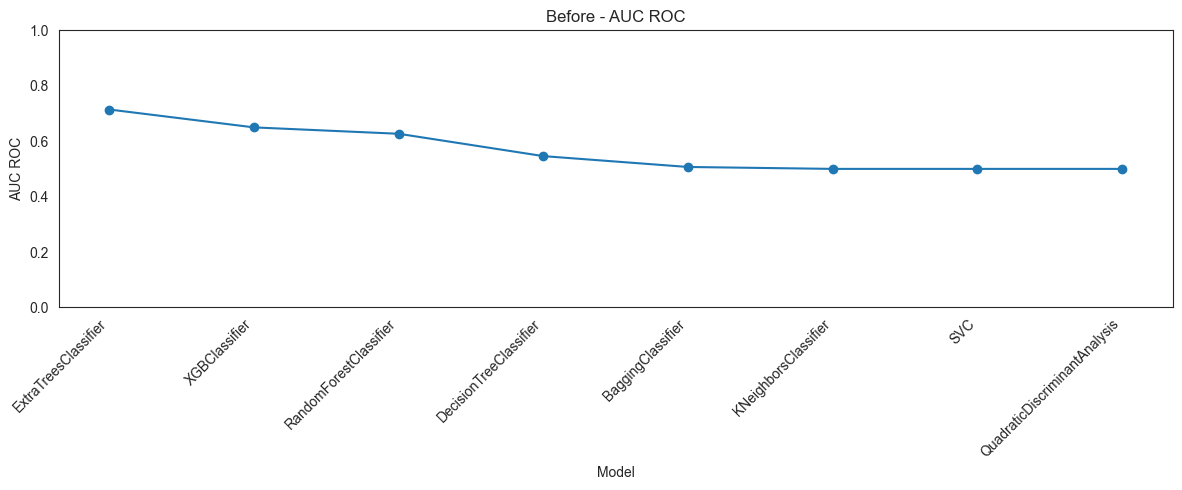

In [24]:
def plot_auc_roc_line(df, title="AUC ROC by Model"):
    # Expects columns: "Model", "AUC ROC"
    d = df[["Model", "AUC ROC"]].copy()
    d["AUC ROC"] = pd.to_numeric(d["AUC ROC"], errors="coerce")
    d = d.dropna().sort_values("AUC ROC", ascending=False)

    plt.figure(figsize=(12, 5))
    plt.plot(d["Model"], d["AUC ROC"], marker="o")
    plt.xlabel("Model")
    plt.ylabel("AUC ROC")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()


# Example:
plot_auc_roc_line(df_before_full, title="Before - AUC ROC")


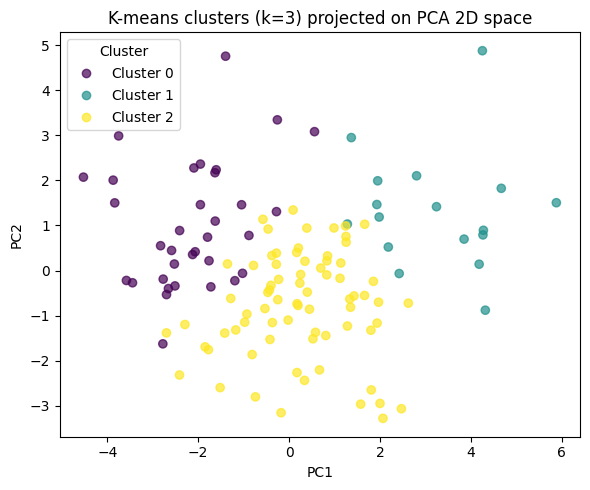

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1) PCA 2 chiều từ X_scaled
pca_2d = PCA(n_components=2)
X_pca2 = pca_2d.fit_transform(X_scaled)   # X_scaled bạn đã tạo cho KMeans

# 2) Vẽ scatter, màu = cluster_k3
plt.figure(figsize=(6, 5))
scatter = plt.scatter(
    X_pca2[:, 0], X_pca2[:, 1],
    c=df_before["cluster_k3"],   # nhãn cụm bạn đã gán
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-means clusters (k=3) projected on PCA 2D space")

# legend cho từng cụm
handles, labels = scatter.legend_elements()
plt.legend(handles, [f"Cluster {l}" for l in labels], title="Cluster")

plt.tight_layout()
plt.show()

In [12]:
# from sklearn.metrics import silhouette_score

# sil_score = silhouette_score(X_scaled, df_before["cluster_k3"])
# print("Silhouette score (k=3):", sil_score)

In [13]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.cluster import KMeans

# k_values = range(2, 8)
# inertias = []

# for k in k_values:
#     km = KMeans(n_clusters=k, random_state=42, n_init=10)
#     km.fit(X_scaled)
#     inertias.append(km.inertia_)   # tổng bình phương khoảng cách trong cụm

# plt.figure(figsize=(6, 4))
# plt.plot(k_values, inertias, marker="o")
# plt.xlabel("Number of clusters (k)")
# plt.ylabel("Inertia (within-cluster sum of squares)")
# plt.title("Elbow plot for K-means")
# plt.xticks(k_values)
# plt.tight_layout()
# plt.show()

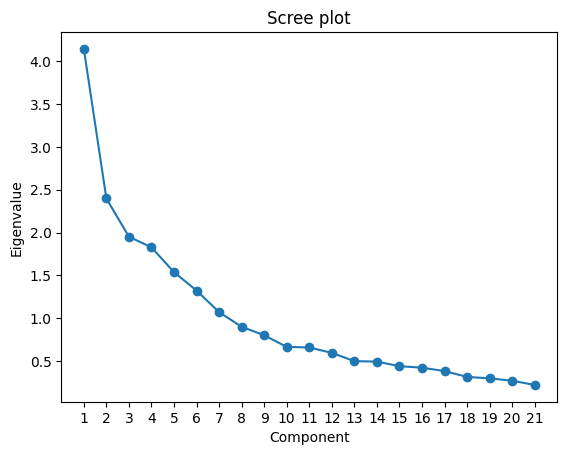

In [14]:
import matplotlib.pyplot as plt
import numpy as np

eigs = pca.explained_variance_   # hoặc eigenvalue bạn đã lưu

plt.plot(range(1, len(eigs)+1), eigs, marker="o")
plt.xlabel("Component")
plt.ylabel("Eigenvalue")
plt.title("Scree plot")
plt.xticks(range(1, len(eigs)+1))
plt.show()

In [15]:
#information gain for intent to quit

import pandas as pd
from sklearn.feature_selection import mutual_info_classif

# 1) Chon X va y
X_ig = df_before[indicator_cols]         
y_ig = df_before["IntentQuit_bin"]        

# 2) Tinh mutual information (information gain gan dung)
# discrete_features=True vi cac bien cua ban la thang diem / nhom
mi = mutual_info_classif(
    X_ig,
    y_ig,
    discrete_features=True,
    random_state=42
)

ig_df = pd.DataFrame({
    "feature": indicator_cols,
    "information_gain": mi
})

ig_df = ig_df.sort_values("information_gain", ascending=False).reset_index(drop=True)

print("Information gain for IntentQuit_bin:")
print(ig_df)


Information gain for IntentQuit_bin:
              feature  information_gain
0                 SS1              0.08
1                 SS2              0.07
2                 SS3              0.06
3   short_term_memory              0.05
4           self_harm              0.05
5                 FP2              0.05
6      family_history              0.04
7          depression              0.04
8                 AP2              0.03
9                 AP3              0.03
10                AP1              0.03
11         work_hours              0.02
12     sleep_duration              0.02
13                AP4              0.02
14                FP1              0.01
15                FS1              0.01
16            anxiety              0.01
17                FS2              0.01
18      dietary_habit              0.01
19                FS3              0.00
20       nicotine_use              0.00


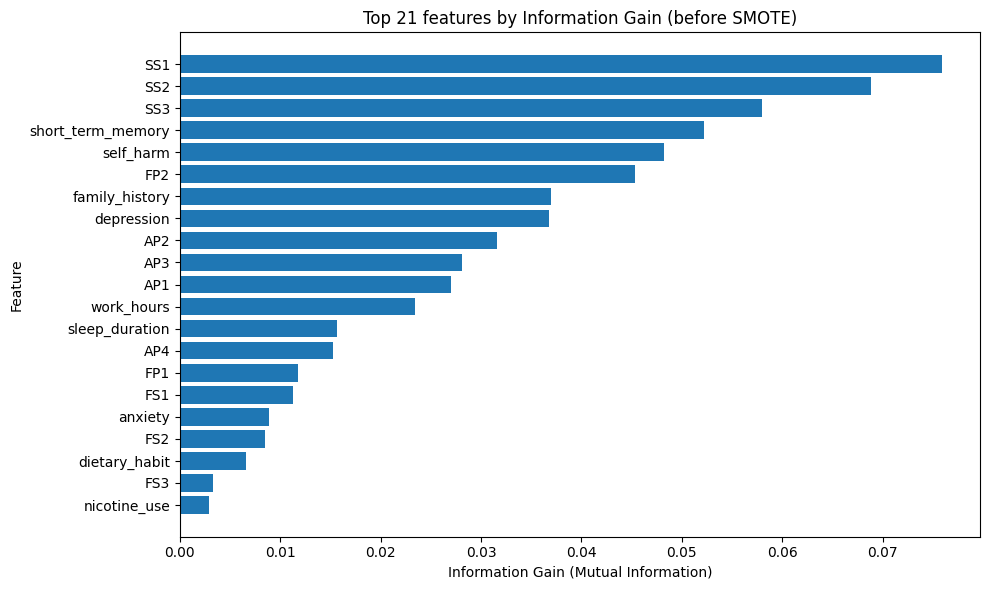

In [16]:
import matplotlib.pyplot as plt

top_n = 21
plot_df = ig_df.head(top_n).copy()

plt.figure(figsize=(10, 6))
plt.barh(plot_df["feature"][::-1], plot_df["information_gain"][::-1])
plt.xlabel("Information Gain (Mutual Information)")
plt.ylabel("Feature")
plt.title(f"Top {top_n} features by Information Gain (before SMOTE)")
plt.tight_layout()
plt.savefig("information_gain_bar_before_smote.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

# 1) PCA: lay 5 component dau (ban co the doi so)
pca_svm = PCA(n_components=7, random_state=42)
X_pca_svm = pca_svm.fit_transform(X_scaled)

print("Explained variance ratio:", pca_svm.explained_variance_ratio_.round(3))
print("Total explained:", round(pca_svm.explained_variance_ratio_.sum(), 3))
# 2) Train / test split tren du lieu PCA
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_pca_svm,
    y_quit,
    test_size=0.3,
    random_state=42,
    stratify=y_quit
)

# 3) SVM classifier (kernel RBF)
svm_clf = SVC(
    kernel="rbf",
    probability=True,   # de tinh AUC ROC
    random_state=42
)
svm_clf.fit(X_train_svm, y_train_svm)

# 4) Du doan
y_pred_svm = svm_clf.predict(X_test_svm)
y_prob_svm = svm_clf.predict_proba(X_test_svm)[:, 1]

# 5) Metric danh gia
print("=== SVM on PCA components ===")
print("Accuracy:", round(accuracy_score(y_test_svm, y_pred_svm), 3))
print("AUC ROC:", round(roc_auc_score(y_test_svm, y_prob_svm), 3))

print("\nConfusion matrix (SVM + PCA):")
print(confusion_matrix(y_test_svm, y_pred_svm))

print("\nClassification report (SVM + PCA):")
print(classification_report(y_test_svm, y_pred_svm, digits=3))

Explained variance ratio: [0.196 0.113 0.092 0.086 0.073 0.062 0.05 ]
Total explained: 0.673
=== SVM on PCA components ===
Accuracy: 0.842
AUC ROC: 0.719

Confusion matrix (SVM + PCA):
[[31  0]
 [ 6  1]]

Classification report (SVM + PCA):
              precision    recall  f1-score   support

           0      0.838     1.000     0.912        31
           1      1.000     0.143     0.250         7

    accuracy                          0.842        38
   macro avg      0.919     0.571     0.581        38
weighted avg      0.868     0.842     0.790        38



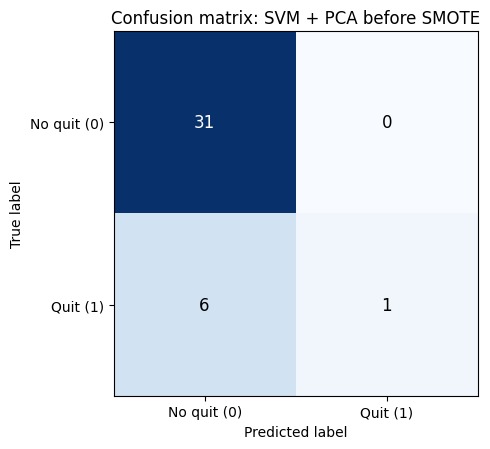

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_smote = confusion_matrix(y_test_svm, y_pred_svm)

fig, ax = plt.subplots(figsize=(5.2, 4.6))

im = ax.imshow(cm_smote, cmap="Blues")  # doi mau neu muon

thresh = cm_smote.max() / 2.0
for i in range(cm_smote.shape[0]):
    for j in range(cm_smote.shape[1]):
        ax.text(
            j, i, f"{cm_smote[i, j]}",
            ha="center", va="center",
            color="white" if cm_smote[i, j] > thresh else "black",
            fontsize=12
        )

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["No quit (0)", "Quit (1)"])
ax.set_yticklabels(["No quit (0)", "Quit (1)"])
ax.set_title("Confusion matrix: SVM + PCA before SMOTE")

plt.tight_layout()
plt.show()


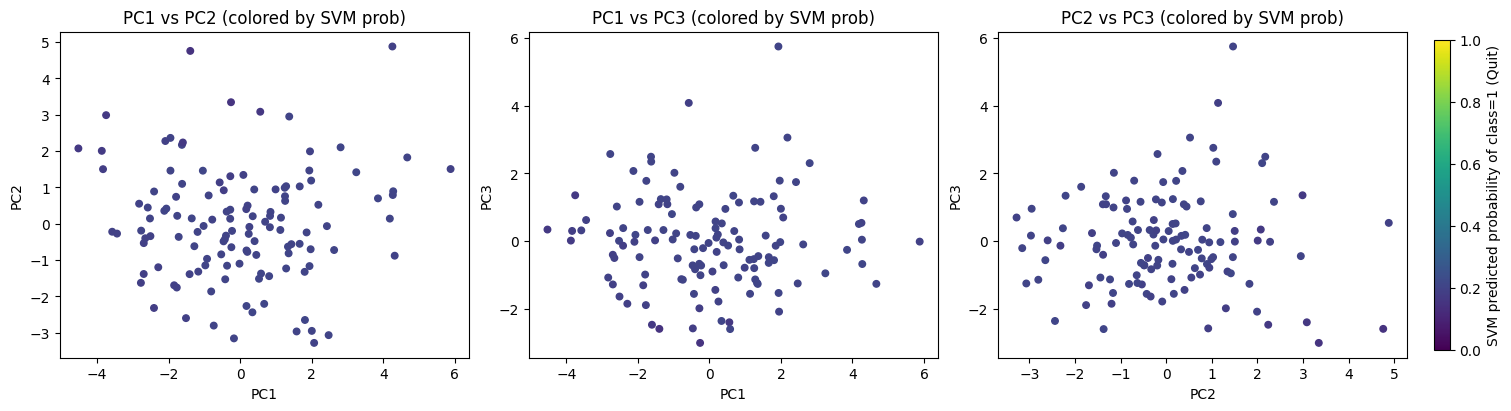

In [19]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# Assumptions (BEFORE):
# - X_scaled: da scale xong (numpy array) cho BEFORE SMOTE
# - y_quit: nhan 0/1 (IntentQuit_bin) tuong ung voi X_scaled

# 1) PCA -> 3 PCs
pca3_before = PCA(n_components=3, random_state=42)
X_pca3_before = pca3_before.fit_transform(X_scaled)

# 2) Train/Test split + train SVM tren 3 PCs (de visualization "dung 3 PC" cho ca model)
X_train3_b, X_test3_b, y_train3_b, y_test3_b = train_test_split(
    X_pca3_before,
    y_quit,
    test_size=0.3,
    random_state=42,
    stratify=y_quit
)

svm_clf_3pc_before = SVC(kernel="rbf", probability=True, random_state=42)
svm_clf_3pc_before.fit(X_train3_b, np.array(y_train3_b).ravel())

# 3) Prob class=1 tren toan bo data (de to mau)
y_prob_all_before = svm_clf_3pc_before.predict_proba(X_pca3_before)[:, 1]

# 4) Ve 3 cap: (PC1,PC2), (PC1,PC3), (PC2,PC3)
pairs = [
    (0, 1, "PC1", "PC2"),
    (0, 2, "PC1", "PC3"),
    (1, 2, "PC2", "PC3"),
]

cmap_name = "viridis"  # thu "plasma", "magma", "coolwarm" neu muon doi mau

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

sc = None
for ax, (i, j, xi, yj) in zip(axes, pairs):
    sc = ax.scatter(
        X_pca3_before[:, i],
        X_pca3_before[:, j],
        c=y_prob_all_before,
        s=22,
        cmap=cmap_name,
        vmin=0.0,
        vmax=1.0
    )
    ax.set_xlabel(xi)
    ax.set_ylabel(yj)
    ax.set_title(f"{xi} vs {yj} (colored by SVM prob)")

# 1 colorbar chung cho ca 3 plot
cbar = fig.colorbar(sc, ax=axes, shrink=0.95, pad=0.02)
cbar.set_label("SVM predicted probability of class=1 (Quit)")

plt.show()


In [20]:
import numpy as np
import pandas as pd

print("y true counts:\n", pd.Series(y_quit).value_counts())
print("y pred counts:\n", pd.Series(svm_clf_3pc_before.predict(X_pca3_before)).value_counts())

print("prob summary:")
print("min =", y_prob_all_before.min(), "max =", y_prob_all_before.max(), "mean =", y_prob_all_before.mean())
print("p05,p50,p95 =", np.percentile(y_prob_all_before, [5, 50, 95]))

y true counts:
 IntentQuit_bin
0    100
1     24
Name: count, dtype: int64
y pred counts:
 0    121
1      3
Name: count, dtype: int64
prob summary:
min = 0.14558283555407514 max = 0.20954415835112597 mean = 0.19704635616760416
p05,p50,p95 = [0.1751581  0.19991917 0.20514092]


Correlation matrix:
                   dietary_habit  nicotine_use  work_hours  AP1   AP2   AP3  \
dietary_habit               1.00          0.14       -0.08 0.29  0.22  0.12   
nicotine_use                0.14          1.00        0.25 0.12 -0.03 -0.10   
work_hours                 -0.08          0.25        1.00 0.05 -0.00 -0.08   
AP1                         0.29          0.12        0.05 1.00  0.56  0.35   
AP2                         0.22         -0.03       -0.00 0.56  1.00  0.52   
AP3                         0.12         -0.10       -0.08 0.35  0.52  1.00   
AP4                         0.15          0.11        0.10 0.48  0.55  0.48   
FS1                         0.08         -0.12        0.14 0.09  0.14  0.11   
FS2                         0.01         -0.11       -0.03 0.08  0.12  0.12   
FS3                         0.07         -0.09       -0.06 0.13  0.16  0.24   
FP1                        -0.09         -0.31       -0.03 0.04  0.13  0.19   
FP2                         0.08

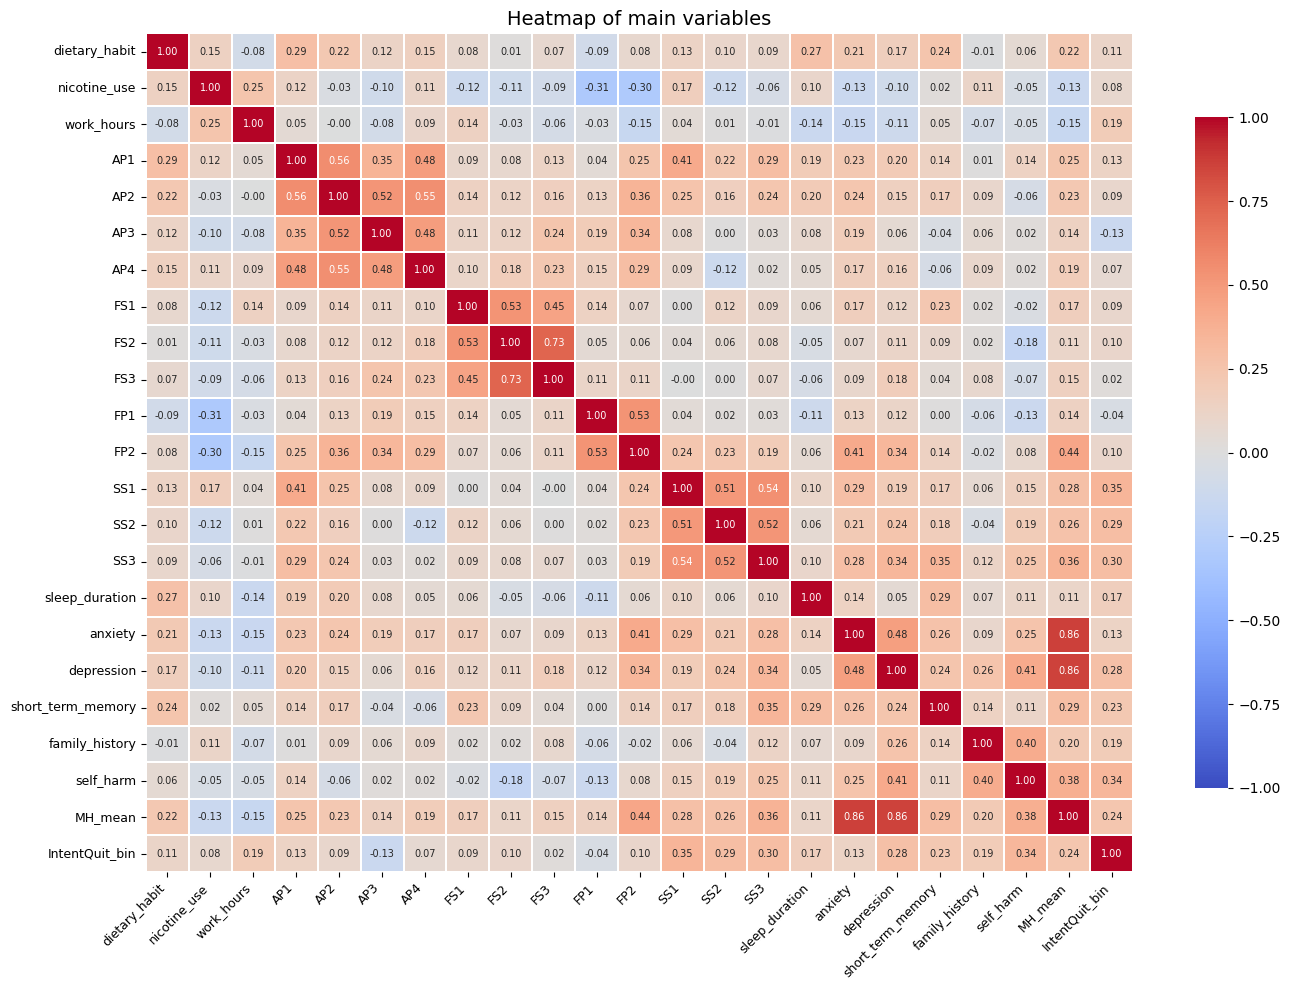

In [21]:
scale_vars = df_before.select_dtypes(include=["int64", "float64", "Int64"]).columns.tolist()

cols_to_drop = ["study_year", "intent_to_quit"]
scale_vars = [c for c in scale_vars if c not in cols_to_drop]

import matplotlib.pyplot as plt
import seaborn as sns

# 1) Ma tran tuong quan Pearson
corr = df_before[scale_vars].corr()

print("Correlation matrix:")
print(corr.round(3))

# 2) Ve heatmap (correlogram) - FIX de do bi dinh
plt.figure(figsize=(14, 10))  

ax = sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    annot_kws={"size": 7},     
    linewidths=0.3,            
    cbar_kws={"shrink": 0.8}  
)

plt.title("Heatmap of main variables", fontsize=14)

# xoay + giam font tick
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig("heatmap_mainvars.png", dpi=300, bbox_inches="tight")
plt.show()


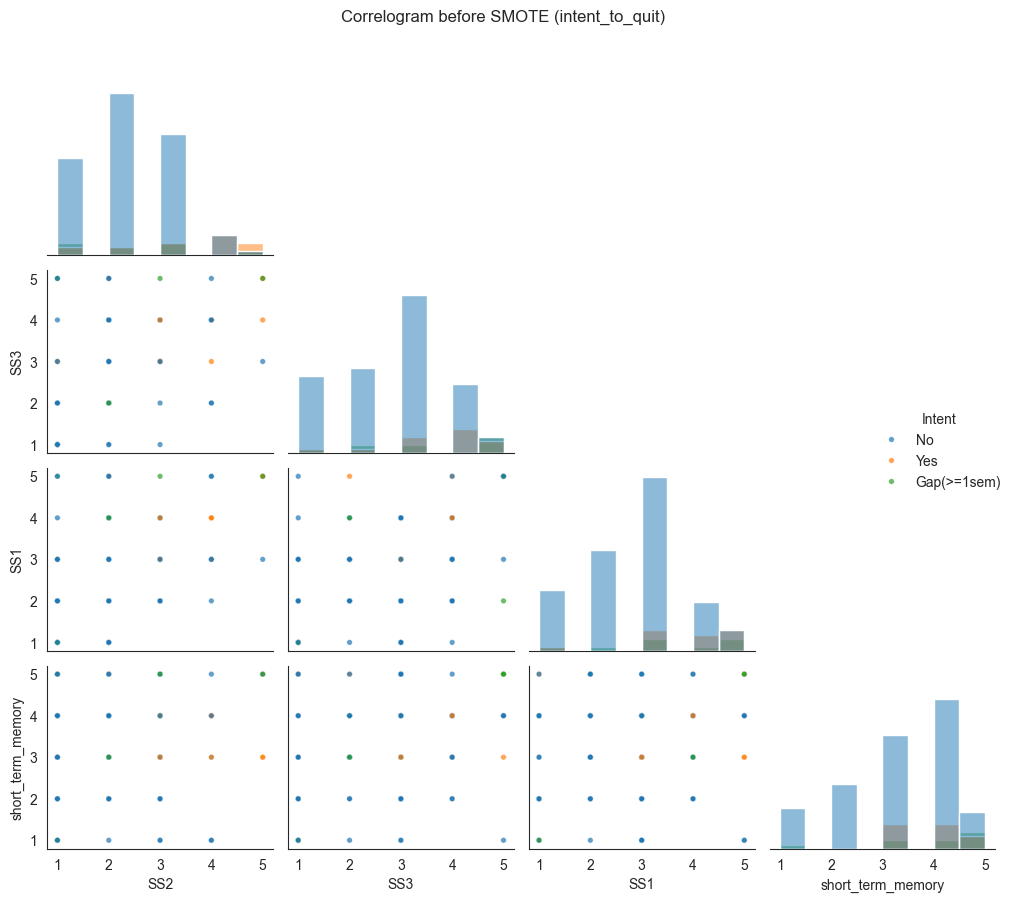

In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif

# ========= CHON DATASET =========
# df_plot = df_before   # truoc SMOTE     # sau SMOTE

# ========= CHON TARGET =========
# Neu ban muon ve theo 3 nhom (1,3,5) thi dung intent_to_quit
target_col = "intent_to_quit"

# Neu ban muon ve theo nhi phan (0/1) thi doi sang IntentQuit_bin
# target_col = "IntentQuit_bin"

# ========= CHON CAC FEATURE LIEN QUAN INTENT =========
# Cach 1: neu ban da co list indicator_cols / indicator_cols_smote thi dung no
# feature_cols = indicator_cols           # truoc SMOTE
# feature_cols = indicator_cols_smote     # sau SMOTE

# Cach 2 (an toan): tu dong lay cac cot numeric, bo cac cot khong muon
drop_cols = {"study_year", "MH_mean", "IntentQuit_bin", "intent_to_quit"}
feature_cols = [
    c for c in df_before.select_dtypes(include=["int64", "float64", "Int64"]).columns
                  if c not in drop_cols
]

# ========= (TU CHON) LAY TOP N FEATURE DE DE NHIN HON =========
# Neu ban muon ve HET TAT CA feature_cols, dat top_n = None
top_n = 4  # doi 8-15 cho de nhin; dat None neu muon full

df_tmp = df_before[feature_cols + [target_col]].dropna()
X = df_tmp[feature_cols]
y = df_tmp[target_col].astype(int)

if top_n is not None:
    mi = mutual_info_classif(X, y, discrete_features=True, random_state=42)
    mi_s = pd.Series(mi, index=feature_cols).sort_values(ascending=False)
    use_cols = mi_s.head(top_n).index.tolist()
else:
    use_cols = feature_cols

df_pair = df_tmp[use_cols + [target_col]].copy()

# ========= LABEL CHO HUE =========
if target_col == "intent_to_quit":
    label_map = {1: "No", 3: "Gap(>=1sem)", 5: "Yes"}
    df_pair["intent_label"] = df_pair[target_col].map(label_map).fillna(df_pair[target_col].astype(str))
    hue_col = "intent_label"
else:
    label_map = {0: "NoQuit", 1: "Quit"}
    df_pair["intent_label"] = df_pair[target_col].map(label_map).fillna(df_pair[target_col].astype(str))
    hue_col = "intent_label"

# ========= VE PAIR "CORRELOGRAM" =========
sns.set_style("white")

g = sns.PairGrid(
    df_pair,
    vars=use_cols,
    hue=hue_col,
    corner=True,
    height=2.2
)

# Duong cheo: histogram
g.map_diag(sns.histplot, bins=8)

# Tam giac duoi: scatter (cham) + to mau theo intent
g.map_lower(sns.scatterplot, s=16, alpha=0.7)

g.add_legend(title="Intent")

plt.suptitle(f"Correlogram before SMOTE ({target_col})", y=1.02)
plt.tight_layout()
plt.show()